In [45]:
import numpy as np
import pandas as pd

# Parameters
T = 5
r = 0.03
X0 = 10
gamma1 = 0.5
gamma2_values = [0.005, 0.01]

# Volatility parameters
sigma1 = 0.16
sigma2 = 0.48
rho = 0.09

sigma = np.array([
    [sigma1, 0.0],
    [sigma2 * rho, sigma2 * np.sqrt(1 - rho**2)]
])

Sigma = sigma @ sigma.T
Sigma_inv = np.linalg.inv(Sigma)

# Mean return functions depending on ESG rating
def mu_from_G(G):
    G1, G2 = G

    # Asset 1
    if G1 == 1.0:
        mu1 = 0.12
    elif G1 == 0.5:
        mu1 = 0.08
    
    # Asset 2
    if G2 == -0.5:
        mu2 = 0.22
    elif G2 == -1.0:
        mu2 = 0.20

    return np.array([mu1, mu2])


# Panels A-D
panels = {
    "Panel A: G1=1, G2=-0.5": np.array([1.0, -0.5]),
    "Panel B: G1=1, G2=-1": np.array([1.0, -1.0]),
    "Panel C: G1=0.5, G2=-0.5": np.array([0.5, -0.5]),
    "Panel D: G1=0.5, G2=-1": np.array([0.5, -1.0]),
}

all_tables = {}

for panel_name, G in panels.items():
    mu = mu_from_G(G)
    theta = mu - r * np.ones(2)

    # Local mean-variance component
    pi_Merton = (1 / (gamma1 * X0)) * np.exp(-r * T) * (Sigma_inv @ theta)

    rows = []

    # Mixed investor
    for i in range(2):
        rows.append({
            "Investor": "Brown investor",
            "Asset": f"Asset {i+1}",
            "Merton": pi_Merton[i],
            "ESG": np.nan,
            "Combined": pi_Merton[i]
        })

    # Green investors
    for gamma2 in gamma2_values:
        pi_ESG = (
            gamma2 / (gamma1**2 * X0)
            * np.exp(-r * T)
            * (Sigma_inv @ G)
        )
        pi_green = pi_Merton + pi_ESG

        for i in range(2):
            rows.append({
                "Investor": f"Green investor, gamma2={gamma2}",
                "Asset": f"Asset {i+1}",
                "Merton": pi_Merton[i],
                "ESG": pi_ESG[i],
                "Combined": pi_green[i]
            })

    all_tables[panel_name] = pd.DataFrame(rows)

# Print results
for panel_name, df in all_tables.items():
    print("\n" + panel_name)
    print(df.round(4).to_string(index=False))



Panel A: G1=1, G2=-0.5
                    Investor   Asset  Merton     ESG  Combined
              Brown investor Asset 1  0.5715     NaN    0.5715
              Brown investor Asset 2  0.1248     NaN    0.1248
Green investor, gamma2=0.005 Asset 1  0.5715  0.0688    0.6403
Green investor, gamma2=0.005 Asset 2  0.1248 -0.0058    0.1190
 Green investor, gamma2=0.01 Asset 1  0.5715  0.1376    0.7091
 Green investor, gamma2=0.01 Asset 2  0.1248 -0.0116    0.1132

Panel B: G1=1, G2=-1
                    Investor   Asset  Merton     ESG  Combined
              Brown investor Asset 1  0.5756     NaN    0.5756
              Brown investor Asset 2  0.1097     NaN    0.1097
Green investor, gamma2=0.005 Asset 1  0.5756  0.0698    0.6454
Green investor, gamma2=0.005 Asset 2  0.1097 -0.0096    0.1002
 Green investor, gamma2=0.01 Asset 1  0.5756  0.1397    0.7152
 Green investor, gamma2=0.01 Asset 2  0.1097 -0.0191    0.0906

Panel C: G1=0.5, G2=-0.5
                    Investor   Asset  Merton  

Below we change G halfway through the investment horizon. We let all other parameters be fixed, also mu.

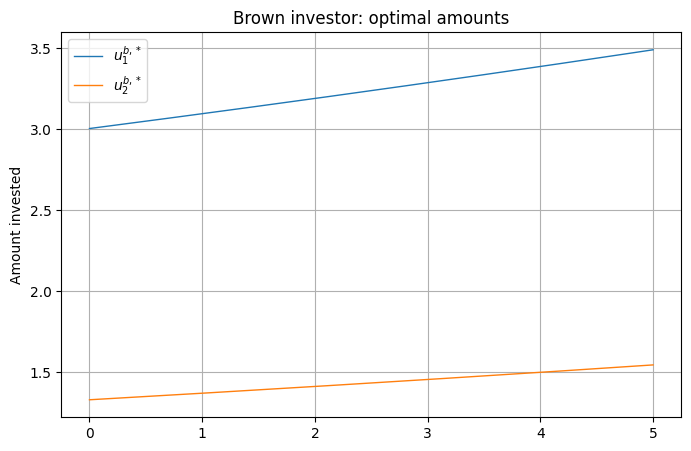

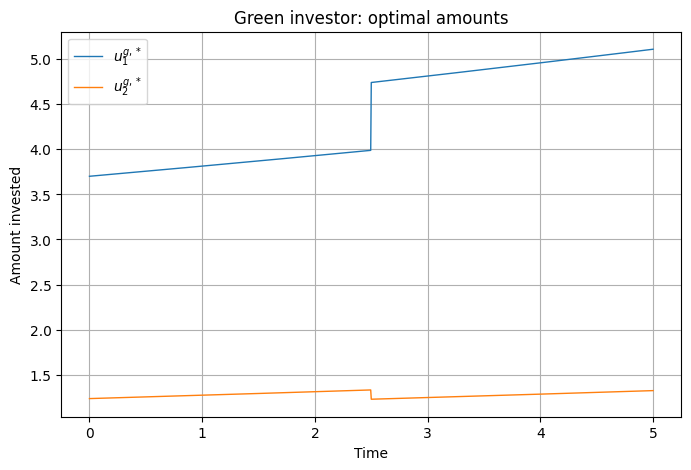

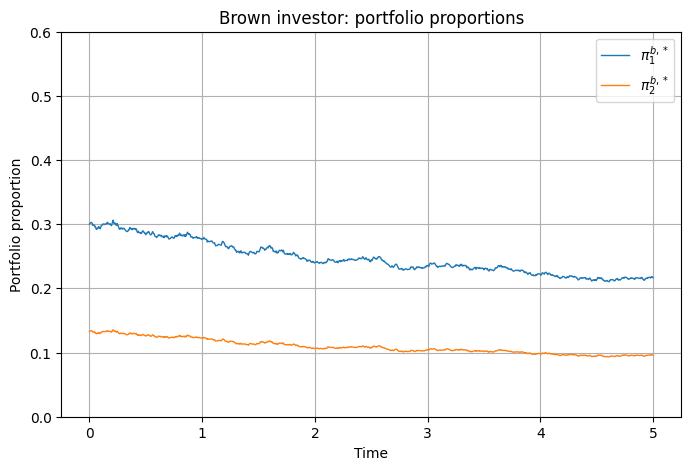

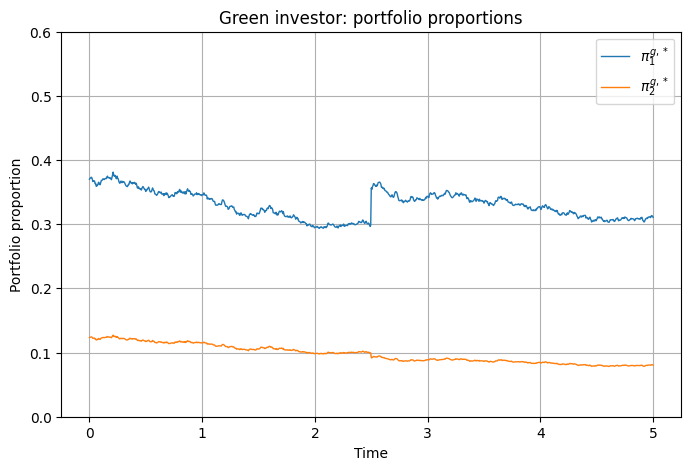

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

T = 5
Ndt = 1000
dt = T / Ndt
time = np.linspace(0, T, Ndt + 1)

X0 = 10
r = 0.03
gamma1 = 0.5
gamma2 = 0.01

mu=np.array([0.08, 0.22])  
theta = mu - r * np.ones(2)  
sigma1 = 0.16
sigma2 = 0.48
rho = 0.09

sigma = np.array([
    [sigma1, 0.0],
    [rho * sigma2, np.sqrt(1 - rho**2) * sigma2]
])

Sigma = sigma @ sigma.T
Sigma_inv = np.linalg.inv(Sigma)

def G_time(t, T):
    if t < T/2:
        return np.array([0.5, -0.5])
    else:
        return np.array([1.0, -1.0])


def simulate_wealth_varying_G(
    X0, mu, sigma, gamma1, gamma2, Sigma, r, theta, T, Ndt, Nsims=100):
    dt = T / Ndt
    time = np.linspace(0, T, Ndt + 1)

    X_b = np.zeros((Ndt + 1, Nsims))
    X_g = np.zeros((Ndt + 1, Nsims))

    X_b[0, :] = X0
    X_g[0, :] = X0

    Sigma_inv = np.linalg.inv(Sigma)

    # Store optimal amounts u_t
    u_b_values = np.zeros((Ndt + 1, 2))
    u_g_values = np.zeros((Ndt + 1, 2))

    for idx in range(Ndt):
        t = time[idx]
        G = G_time(t, T)

        # Optimal amount for brown investor
        u_b = ((1 / gamma1)* np.exp(-r * (T - t))* (Sigma_inv @ theta))

        # Optimal amount for green investor
        u_g = ((1 / gamma1)* np.exp(-r * (T - t))* (Sigma_inv @ theta)+ (gamma2 / gamma1**2)* np.exp(-r * (T - t))* (Sigma_inv @ G))

        u_b_values[idx, :] = u_b
        u_g_values[idx, :] = u_g

        Z = np.random.randn(2, Nsims)
        dW = np.sqrt(dt) * Z

        # Euler discretization of wealth
        X_b[idx + 1, :] = (X_b[idx, :]+ (r * X_b[idx, :] + u_b.T @ theta) * dt+ (u_b.T @ sigma @ dW))

        X_g[idx + 1, :] = (X_g[idx, :]+ (r * X_g[idx, :] + u_g.T @ theta) * dt+ (u_g.T @ sigma @ dW))

    # Store final value of u at T
    G = G_time(T, T)

    u_b_values[-1, :] = (
        (1 / gamma1)
        * np.exp(-r * (T - T))
        * (Sigma_inv @ theta)
    )

    u_g_values[-1, :] = (
        (1 / gamma1)
        * np.exp(-r * (T - T))
        * (Sigma_inv @ theta)
        + (gamma2 / gamma1**2)
        * np.exp(-r * (T - T))
        * (Sigma_inv @ G)
    )

    # Convert amounts to proportions
    pi_b_values = u_b_values[:, :, None] / X_b[:, None, :]
    pi_g_values = u_g_values[:, :, None] / X_g[:, None, :]

    return time, X_b, X_g, u_b_values, u_g_values, pi_b_values, pi_g_values


time, X_b, X_g, u_b, u_g, pi_b, pi_g = simulate_wealth_varying_G(
    X0=X0,
    mu=mu,
    sigma=sigma,
    gamma1=gamma1,
    gamma2=gamma2,
    Sigma=Sigma,
    r=r,
    theta=theta,
    T=T,
    Ndt=Ndt,
    Nsims=100
)

path = 0

# Plot u for brown investor
plt.figure(figsize=(8, 5))
plt.plot(time, u_b[:, 0], label=r"$u^{b,*}_1$",linewidth=1)
plt.plot(time, u_b[:, 1], label=r"$u^{b,*}_2$",linewidth=1)
plt.ylabel("Amount invested")
plt.title("Brown investor: optimal amounts")
plt.legend()
plt.grid(True)
plt.show()

# Plot u for green investor
plt.figure(figsize=(8, 5))
plt.plot(time, u_g[:, 0], label=r"$u^{g,*}_1$",linewidth=1)
plt.plot(time, u_g[:, 1], label=r"$u^{g,*}_2$",linewidth=1)
plt.xlabel("Time")
plt.ylabel("Amount invested")
plt.title("Green investor: optimal amounts")
plt.legend()
plt.grid(True)
plt.show()

# Plot pi for brown investor
plt.figure(figsize=(8, 5))
plt.plot(time, pi_b[:, 0, path], label=r"$\pi^{b,*}_1$",linewidth=1)
plt.plot(time, pi_b[:, 1, path], label=r"$\pi^{b,*}_2$",linewidth=1)
plt.xlabel("Time")
plt.ylabel("Portfolio proportion")
plt.title("Brown investor: portfolio proportions")
plt.ylim(0,0.6)
plt.legend()
plt.grid(True)
plt.show()

# Plot pi for green investor
plt.figure(figsize=(8, 5))
plt.plot(time, pi_g[:, 0, path], label=r"$\pi^{g,*}_1$",linewidth=1)
plt.plot(time, pi_g[:, 1, path], label=r"$\pi^{g,*}_2$",linewidth=1)
plt.xlabel("Time")
plt.ylabel("Portfolio proportion")
plt.title("Green investor: portfolio proportions")
plt.ylim(0,0.6)
plt.legend()
plt.grid(True)
plt.show()

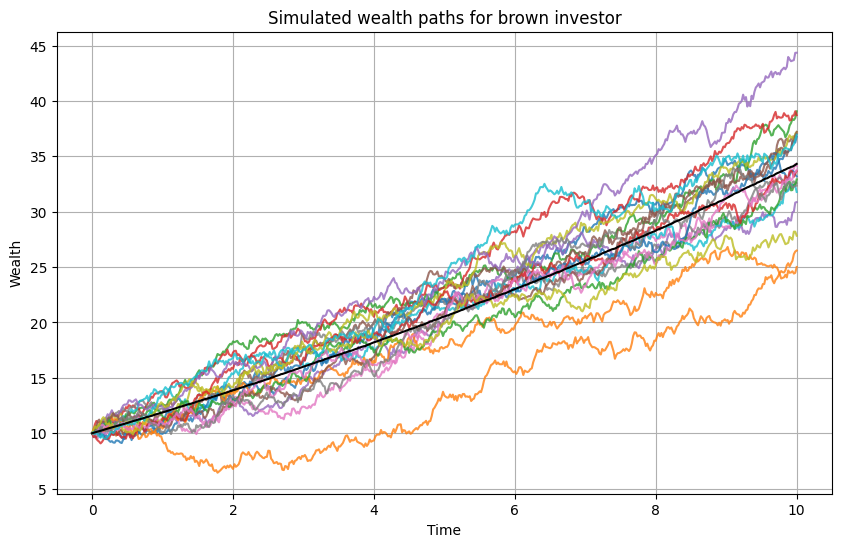

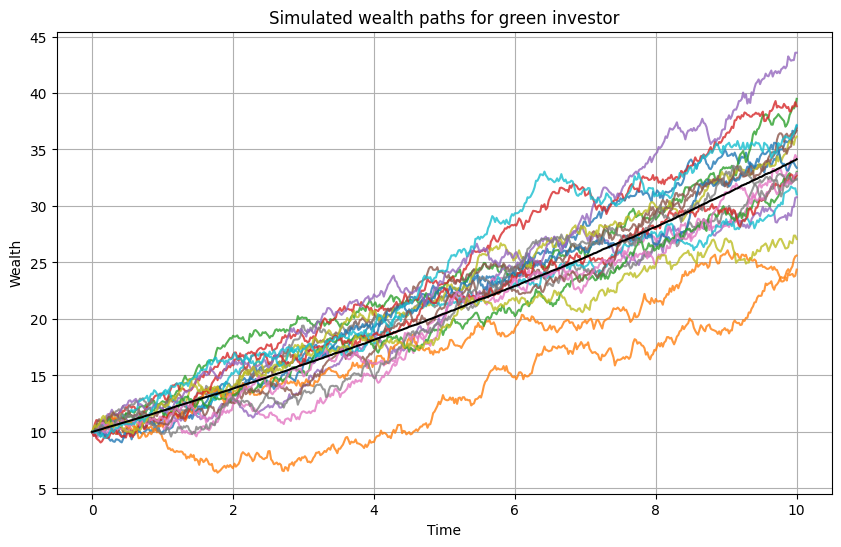

In [51]:
def simulate_wealth(X0,mu,sigma,gamma1,gamma2,Sigma,G,r,theta, T,Ndt,Nsims=100):
    dt=T/Ndt
    time = np.linspace(0,T,Ndt+1)

    X_b=np.zeros((Ndt+1,Nsims))
    X_g=np.zeros((Ndt+1,Nsims))

    X_b[0,:]=X0
    X_g[0,:]=X0

    Sigma_inv=np.linalg.inv(Sigma)


    for idx in range(Ndt):
        t=time[idx]

        #Optimal amount for brown investor
        u_b=(1/gamma1)*np.exp(-r*(T-t))*Sigma_inv@theta

        #Optimal amount for green investor
        u_g=((1/gamma1)*np.exp(-r*(T-t))*Sigma_inv@theta+(gamma2/gamma1**2)*np.exp(-r*(T-t))*Sigma_inv@G)

        Z=np.random.randn(2,Nsims)
        dW=np.sqrt(dt)*Z

        #Euler discretization
        X_b[idx+1,:]=(X_b[idx,:]+(r*X_b[idx,:]+u_b.T@theta)*dt+(u_b.T@sigma@dW))

        X_g[idx+1,:]=(X_g[idx,:]+(r*X_g[idx,:]+u_g.T@theta)*dt+(u_g.T@sigma@dW))

    return time, X_b,X_g


# Parameters
T = 10
Ndt=500
Nsims=10000
r = 0.03
X0 = 10
gamma1 = 0.5
gamma2=0.01

G = np.array([1, -0.5])

mu = np.array([0.12, 0.22])
theta = mu - r * np.ones(2)

# Volatility parameters
sigma1 = 0.20
sigma2 = 0.20
rho = 0.09

sigma = np.array([
    [sigma1, 0.0],
    [sigma2 * rho, sigma2 * np.sqrt(1 - rho**2)]
])

Sigma = sigma @ sigma.T
Sigma_inv = np.linalg.inv(Sigma)

time, X_b, X_g=simulate_wealth(
    X0=X0,
    r=r,
    T=T,
    mu=mu,
    theta=theta,
    sigma=sigma,
    Sigma=Sigma,
    G=G,
    gamma1=gamma1,
    gamma2=gamma2,
    Ndt=Ndt,
    Nsims=Nsims
)

#Brown investor
plt.figure(figsize=(10, 6))

for i in range(20):
    np.random.seed(123)
    plt.plot(time, X_b[:, i], alpha=0.8)

plt.xlabel("Time")
plt.ylabel("Wealth")
plt.title("Simulated wealth paths for brown investor")
plt.plot(time, np.quantile(X_b, [0.5], axis=1).transpose(), 
                  linewidth=1.5, color='black')
plt.grid(True)
plt.show()

#Green investor

plt.figure(figsize=(10, 6))

for i in range(20):
    np.random.seed(123)
    plt.plot(time, X_g[:, i], alpha=0.8)

plt.plot(time, np.quantile(X_g, [0.5], axis=1).transpose(), 
                  linewidth=1.5, color='black')

plt.xlabel("Time")
plt.ylabel("Wealth")
plt.title("Simulated wealth paths for green investor")
plt.grid(True)
plt.show()

Simulate with Y also

In [55]:

def simulate_wealth(
    X0, sigma, gamma1, gamma2, Sigma, G, r, theta, T, Ndt, Nsims=10000):
    np.random.seed(123)

    dt = T / Ndt
    time = np.linspace(0, T, Ndt + 1)

    X_b = np.zeros((Ndt + 1, Nsims))
    X_g = np.zeros((Ndt + 1, Nsims))
    Y_g = np.zeros((Ndt + 1, Nsims))

    X_b[0, :] = X0
    X_g[0, :] = X0
    Y_g[0, :] = 0.0

    Sigma_inv = np.linalg.inv(Sigma)

    for idx in range(Ndt):
        t = time[idx]

        # Optimal amount for brown investor
        u_b = (
            (1 / gamma1)
            * np.exp(-r * (T - t))
            * (Sigma_inv @ theta)
        )

        # Optimal amount for green investor
        u_g = (
            (1 / gamma1)
            * np.exp(-r * (T - t))
            * (Sigma_inv @ theta)
            + (gamma2 / gamma1**2)
            * np.exp(-r * (T - t))
            * (Sigma_inv @ G)
        )

        Z = np.random.randn(2, Nsims)
        dW = np.sqrt(dt) * Z

        # Euler discretization of wealth
        X_b[idx + 1, :] = (
            X_b[idx, :]
            + (r * X_b[idx, :] + u_b.T @ theta) * dt
            + (u_b.T @ sigma @ dW)
        )

        X_g[idx + 1, :] = (
            X_g[idx, :]
            + (r * X_g[idx, :] + u_g.T @ theta) * dt
            + (u_g.T @ sigma @ dW)
        )

        # Euler discretization of accumulated ESG exposure
        Y_g[idx + 1, :] = (
            Y_g[idx, :]
            + (u_g.T @ G) * np.exp(r * (T - t)) * dt
        )

    return time, X_b, X_g, Y_g

In [65]:
time, X_b, X_g, Y_g = simulate_wealth(
    X0=X0,
    r=r,
    T=T,
    theta=theta,
    sigma=sigma,
    Sigma=Sigma,
    G=G,
    gamma1=gamma1,
    gamma2=gamma2,
    Ndt=Ndt,
    Nsims=Nsims
)

# Expected terminal wealth
EX_b = X_b[-1, :].mean()
EX_g = X_g[-1, :].mean()

# Brown utility of each strategy
EU_brown_strategy = np.mean(-np.exp(-gamma1 * X_b[-1, :]))
EU_green_strategy_from_wealth_only = np.mean(-np.exp(-gamma1 * X_g[-1, :]))

# Green utility of green strategy
EU_green_strategy = np.mean(
    -np.exp(-gamma1 * X_g[-1, :] - gamma2 * Y_g[-1, :])
)

print("Expected terminal wealth:")
print("Brown strategy:", EX_b)
print("Green strategy:", EX_g)

print("\nBrown utility E[-exp(-gamma1 X_T)]:")
print("Brown strategy:", EU_brown_strategy)
print("Green strategy:", EU_green_strategy_from_wealth_only)

print("\nGreen utility E[-exp(-gamma1 X_T - gamma2 Y_T)]:")
print("Green strategy:", EU_green_strategy)

Expected terminal wealth:
Brown strategy: 34.28357541956144
Green strategy: 34.10747451789177

Brown utility E[-exp(-gamma1 X_T)]:
Brown strategy: -8.464759172046497e-06
Green strategy: -8.212555703551971e-06

Green utility E[-exp(-gamma1 X_T - gamma2 Y_T)]:
Green strategy: -7.85819469654218e-06
